<a href="https://colab.research.google.com/github/narayananxyz/deep_learning/blob/main/capstone/Reference_Notebook_Facial_Emotion_Detection_Full_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Facial Emotion Detection**

## **Problem Definition**

**The context:** Why is this problem important to solve?<br>
**The objectives:** What is the intended goal?<br>
**The key questions:** What are the key questions that need to be answered?<br>
**The problem formulation:** What are we trying to solve using data science?



## **About the dataset**

The data set consists of 3 folders, i.e., 'test', 'train', and 'validation'.
Each of these folders has four subfolders:

**‘happy’**: Images of people who have happy facial expressions.<br>
**‘sad’**: Images of people with sad or upset facial expressions.<br>
**‘surprise’**: Images of people who have shocked or surprised facial expressions.<br>
**‘neutral’**: Images of people showing no prominent emotion in their facial expression at all.<br>


## **Mounting the Drive**

**NOTE:**  Please use Google Colab from your browser for this notebook. **Google.colab is NOT a library that can be downloaded locally on your device.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Importing the Libraries**

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import h5py
import random
import cv2
import os
import shutil
import zipfile
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### **Let us load and unzip the data**

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same on your Google drive before executing the code in the next cell.
- In case of any error, please make sure that the path of the file is correct as the path may be different for you.

## IO Performace

IO performace can affect model tuning. The best performace I got was when I extracted the images locally. Copying the zip file into the local VM and extract it there, gives the best performace. We will need other techniques if the dataset is even larger, in this case this data set seems to fit in the disk space goolge colab is offering.

In [3]:
# Step 1 — Copy zip from Drive to local
print("Copying zip file from Drive...")
shutil.copy(
    '/content/drive/MyDrive/mitcourse/capstone/Facial_emotion_images.zip',
    '/content/Facial_emotion_images.zip'
)
print("Copy done!")

# Step 2 — Extract locally
print("Extracting...")
with zipfile.ZipFile('/content/Facial_emotion_images.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
print("Extraction done!")

# Step 3 — Verify structure
print("\nFolder structure:")
for split in ['train', 'validation', 'test']:
    path = f'/content/Facial_emotion_images/{split}'
    if os.path.exists(path):
        print(f"  {split}: {os.listdir(path)}")

# Step 4 -- Use local path

base_path = '/content/Facial_emotion_images/'

Copying zip file from Drive...
Copy done!
Extracting...
Extraction done!

Folder structure:
  train: ['sad', 'neutral', 'surprise', 'happy']
  validation: ['sad', 'neutral', 'surprise', 'happy']
  test: ['sad', 'neutral', 'surprise', 'happy']


## **Visualizing our Classes**

Let's look at our classes.

**Write down your observation for each class. What do you think can be a unique feature of each emotion, that separates it from the remaining classes?**

Let's write a functon as we don't have re-code this for every class.

In [4]:
def show_class_samples(base_path, cls, split='train', samples=16, cols=8):
    cls_path = os.path.join(base_path, split, cls)
    images = random.sample(os.listdir(cls_path), samples)
    rows = samples // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    for j, img_name in enumerate(images):
        img = mpimg.imread(os.path.join(cls_path, img_name))
        axes[j//cols][j%cols].imshow(img, cmap='gray')
        axes[j//cols][j%cols].axis('off')

    plt.suptitle(cls.capitalize(), fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### **Happy**

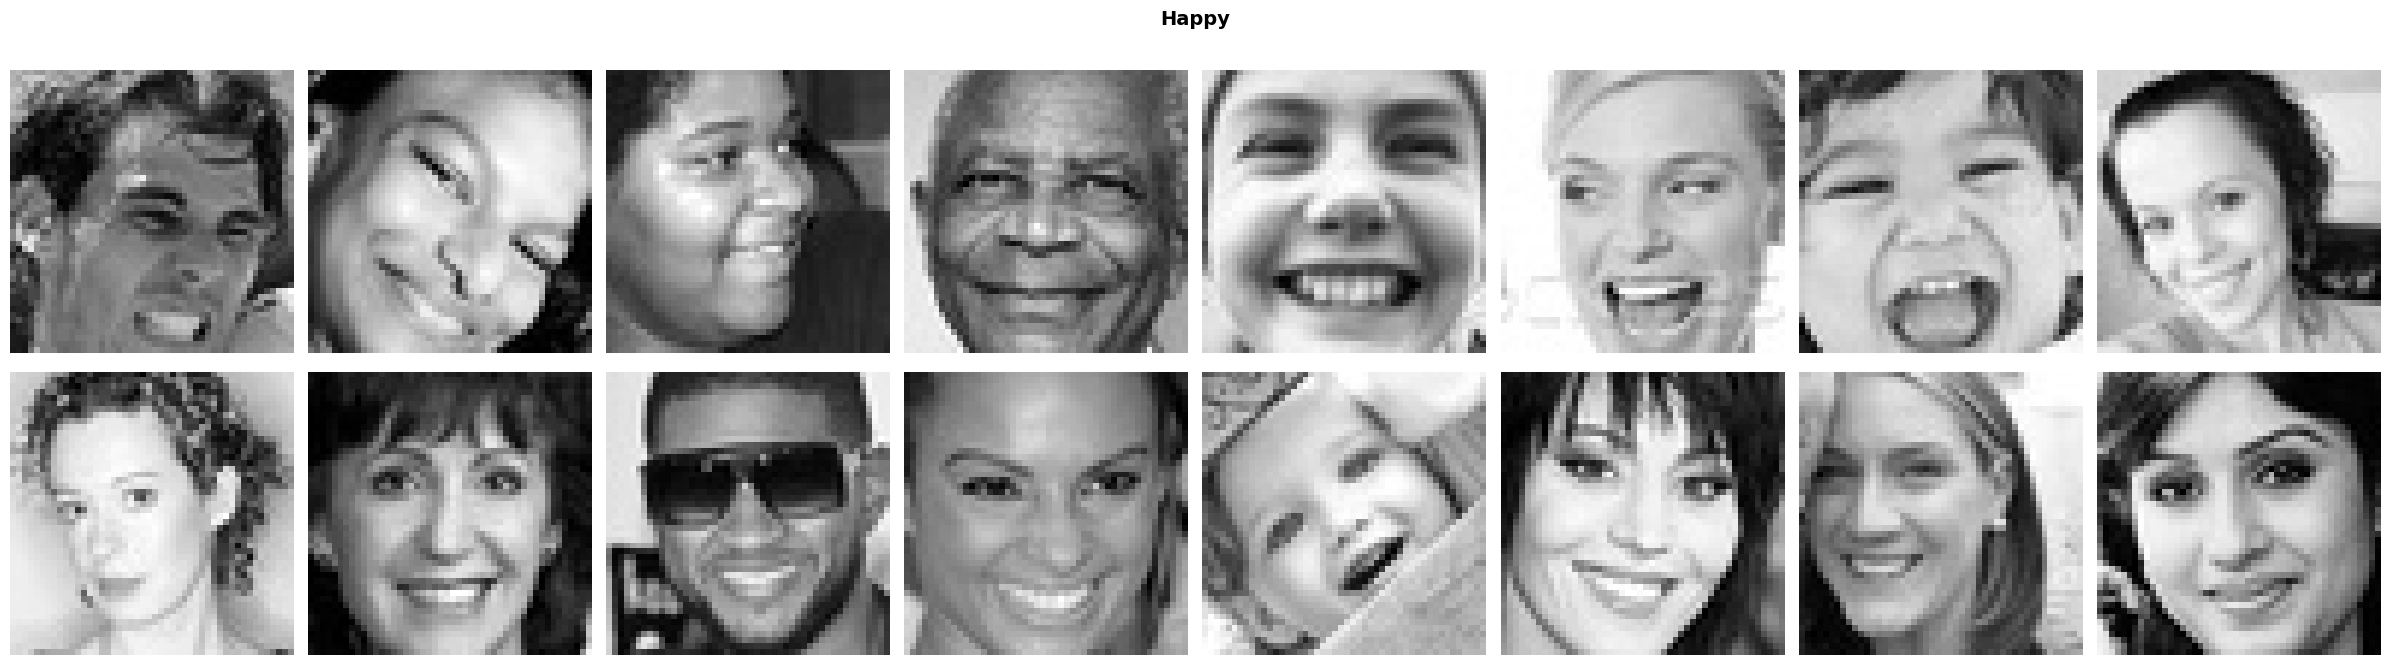

In [5]:
show_class_samples(base_path, 'happy')

**Observations and Insights:**
The most evident feature si the teeth surrounded by upward curved lips. cheek muscles move upward causing eyes to partially close in most cases. This migh be most visually distinct class due to the open mouth with teeth in most images.

### **Sad**

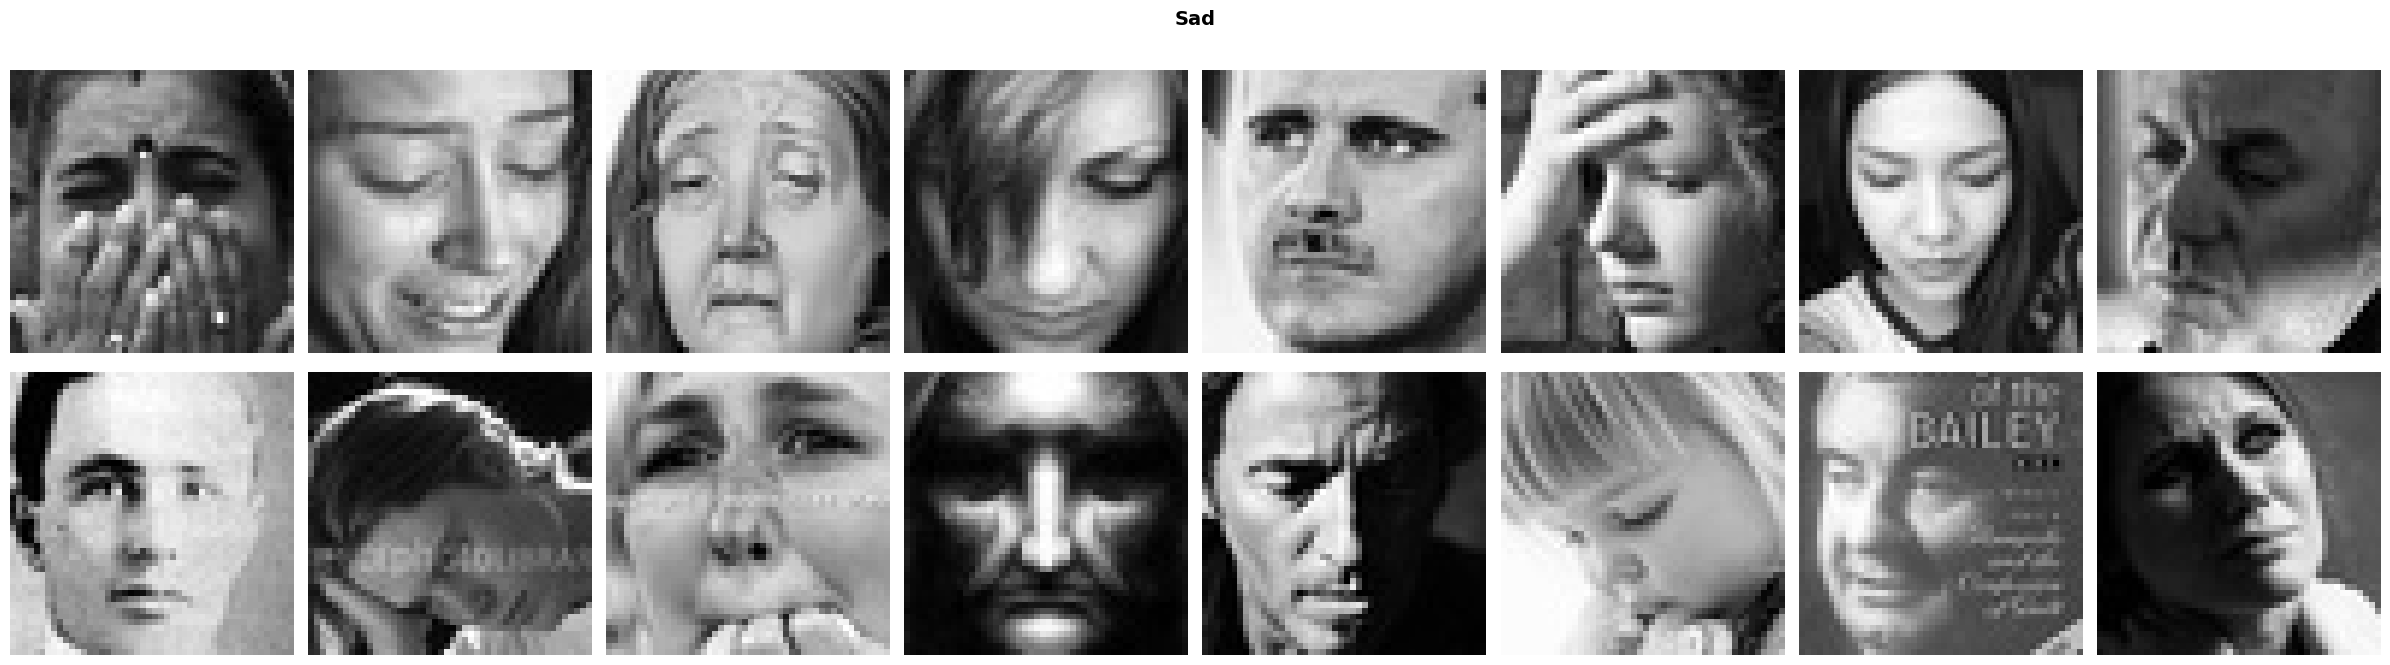

In [6]:
show_class_samples(base_path, 'sad')

**Observations and Insights:**
The face appears more shrunk and drooping eyes—opposite geometry to happy. While cheeks may appear raised in some cases like happy, the key differentiator is the absence of visible teeth. When present, tears are an easy feature. Head tilt downward is also seems in a lot of faces

### **Neutral**

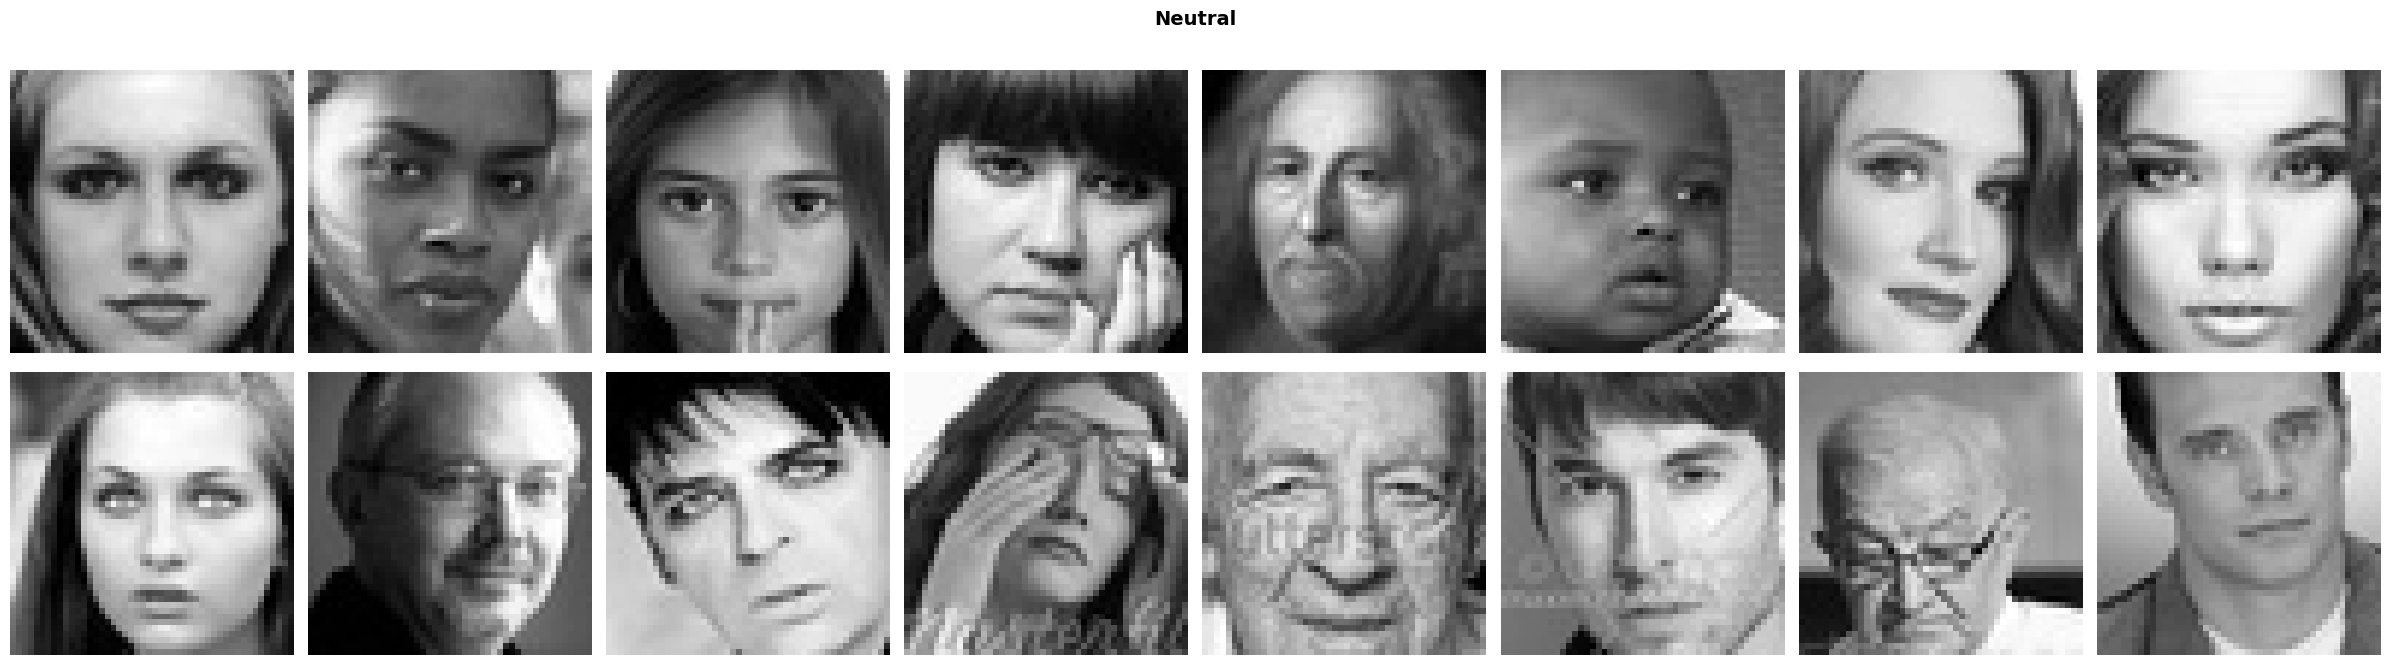

In [7]:
show_class_samples(base_path, 'neutral')

**Observations and Insights:**
This is more closer to sad but without the signs that the sad face gives (no tears, downward mouth etc..). Eyes are fully open and face is more relaxed and symmetric. this is going to hard to identify as it does not have anything significant to distinguish.

### **Surprised**

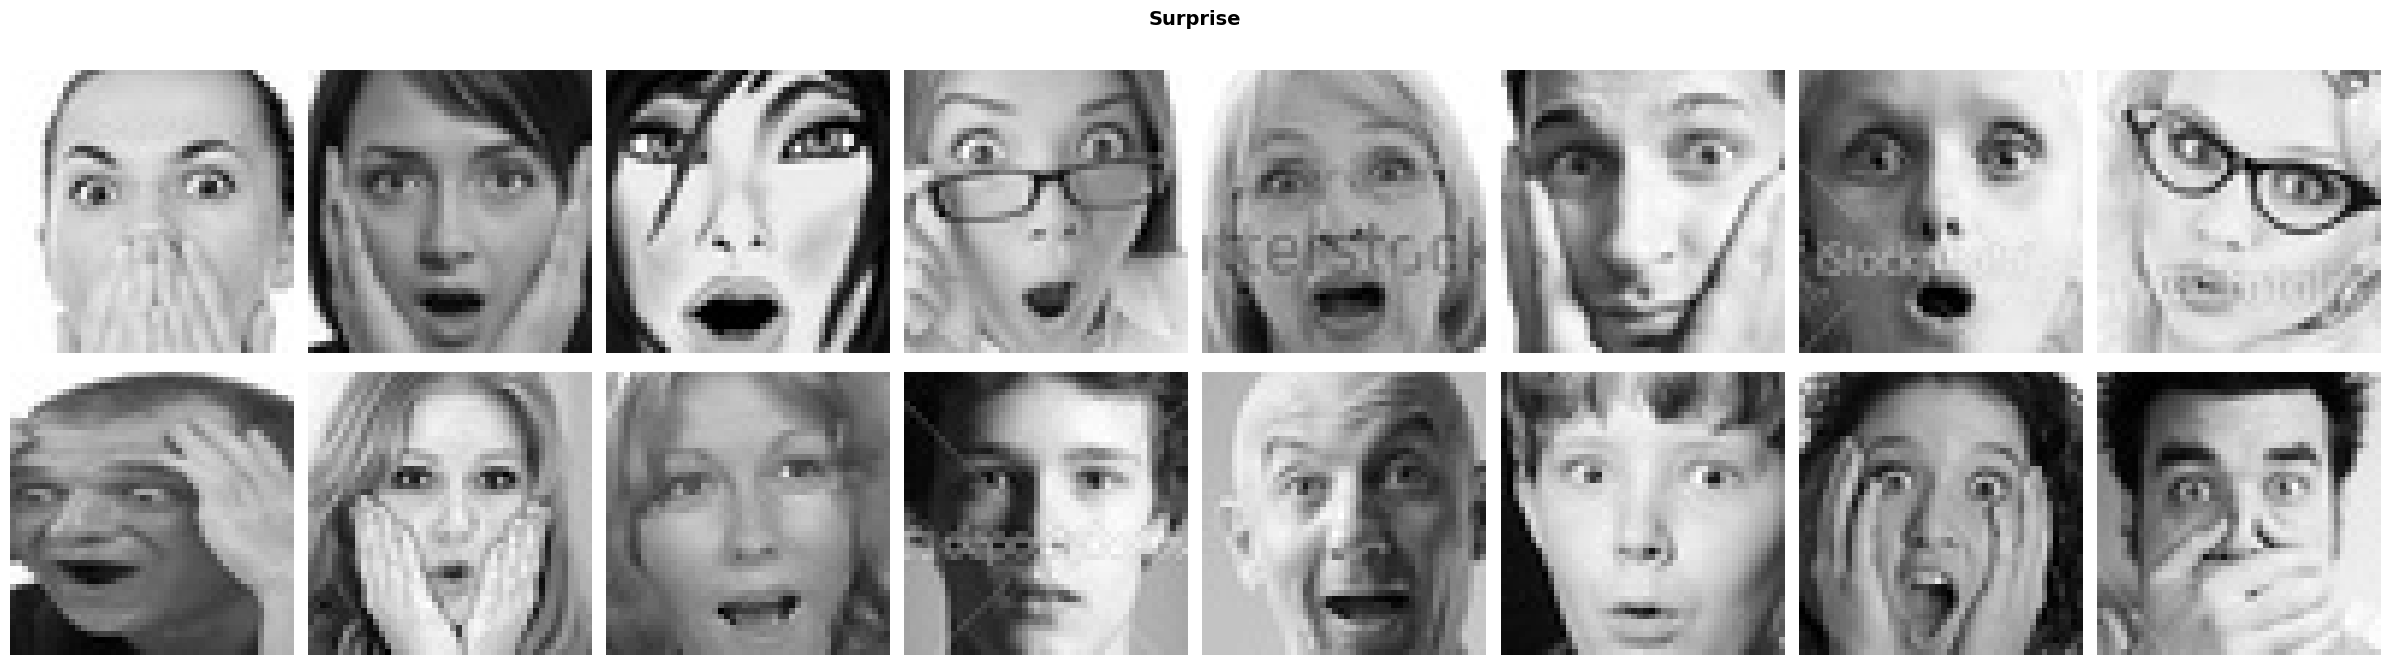

In [8]:
show_class_samples(base_path, 'surprise')

**Observations and Insights:**
Very dominant features in this class. Wide open O shaped mouth and wide open eyes. the vertical strech of the mouth along with a wide open eyes makes it very distinct from happy. This class should be easier to classify than the other classes.

## **Checking Distribution of Classes**

=== Image Count Per Class ===

TRAIN:
  happy     : 3976 images
  sad       : 3982 images
  surprise  : 3173 images
  neutral   : 3978 images
  TOTAL     : 15109 images

VALIDATION:
  happy     : 1825 images
  sad       : 1139 images
  surprise  : 797 images
  neutral   : 1216 images
  TOTAL     : 4977 images

TEST:
  happy     : 32 images
  sad       : 32 images
  surprise  : 32 images
  neutral   : 32 images
  TOTAL     : 128 images



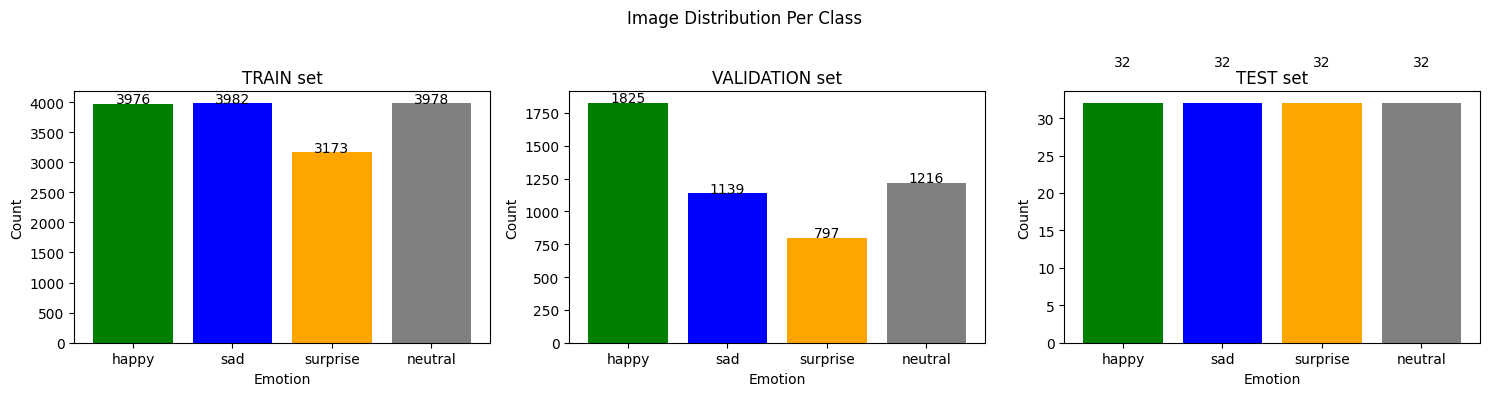

In [9]:

splits = ['train', 'validation', 'test']
emotions = ['happy', 'sad', 'surprise', 'neutral']

print("=== Image Count Per Class ===\n")

counts = {}
for split in splits:
    counts[split] = {}
    print(f"{split.upper()}:")
    total = 0
    for emotion in emotions:
        path = os.path.join(base_path, split, emotion)
        if os.path.exists(path):
            count = len(os.listdir(path))
            counts[split][emotion] = count
            total += count
            print(f"  {emotion:10s}: {count} images")
    print(f"  {'TOTAL':10s}: {total} images\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, split in enumerate(splits):
    values = [counts[split].get(e, 0) for e in emotions]
    axes[idx].bar(emotions, values, color=['green', 'blue', 'orange', 'gray'])
    axes[idx].set_title(f'{split.upper()} set')
    axes[idx].set_xlabel('Emotion')
    axes[idx].set_ylabel('Count')
    for i, v in enumerate(values):
        axes[idx].text(i, v + 5, str(v), ha='center')

plt.suptitle('Image Distribution Per Class')
plt.tight_layout()
plt.show()

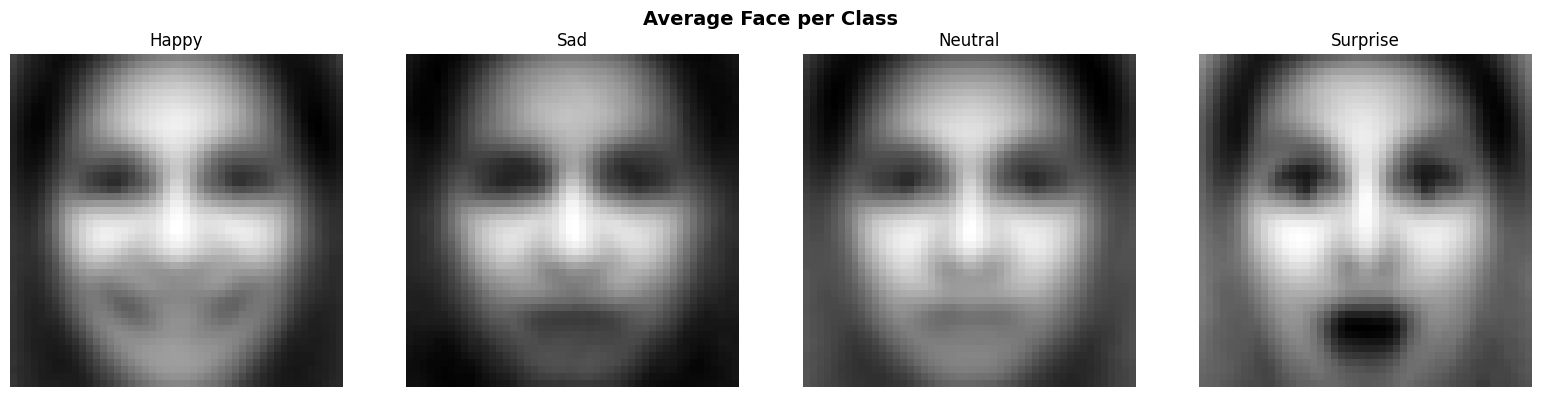

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, cls in enumerate(['happy', 'sad', 'neutral', 'surprise']):
    cls_path = os.path.join(base_path, 'train', cls)
    images = []
    for img_name in os.listdir(cls_path):
        img = mpimg.imread(os.path.join(cls_path, img_name))
        images.append(img)
    avg_face = np.mean(images, axis=0)
    axes[i].imshow(avg_face, cmap='gray')
    axes[i].set_title(cls.capitalize())
    axes[i].axis('off')

plt.suptitle('Average Face per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations and Insights:**

Distribution:
*   Training data is reasonably balanced with suprise being the outlier with fewer samples.
*   Validation data follows the same pattern, surprise is notably lower.
* Test set is perfectly balanced.
* Since the imbalance is not severe we can try to run and observe if there is any precision/recall issues and take call later, if we want to balance things better.

EDA Ideas:
* We can ensure that all the images are of equal size.
* We can get the pixel average of the all the images are geet a good idea on the features. i have the plotted them above.
* We can check all the images against the average and filter any bad or corrupted images.




**Think About It:**
* Are the classes equally distributed? If not, do you think the imbalance is too high? Will it be a problem as we progress?
* Are there any Exploratory Data Analysis tasks that we can do here? Would they provide any meaningful insights?

## **Creating our Data Loaders**

In this section, we are creating data loaders that we will use as inputs to our Neural Network.

**You have two options for the color_mode. You can set it to color_mode = 'rgb' or color_mode = 'grayscale'. You will need to try out both and see for yourself which one gives better performance.**

In [4]:
# Check image size
sample_path = os.path.join(base_path, 'train', 'happy')
sample_img = mpimg.imread(os.path.join(sample_path, os.listdir(sample_path)[0]))
print(sample_img.shape)

(48, 48)


In [26]:
img_size = (48, 48)
batch_size = 32

# Try 'grayscale' or 'rgb'
color_mode = 'grayscale'  # change to 'rgb' to compare

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=img_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    os.path.join(base_path, 'validation'),
    target_size=img_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=img_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

print(f"Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}")
print(f"Class indices: {train_gen.class_indices}")


color_mode = 'rgb'

train_gen_rgb = datagen.flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=img_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_gen_rgb = datagen.flow_from_directory(
    os.path.join(base_path, 'validation'),
    target_size=img_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_gen_rgb = datagen.flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=img_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Train: 15109 | Val: 4977 | Test: 128
Class indices: {'happy': 0, 'neutral': 1, 'sad': 2, 'surprise': 3}
Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


## **Model Building**

**Think About It:**
* Are Convolutional Neural Networks the right approach? Should we have gone with Artificial Neural Networks instead?
* What are the advantages of CNNs over ANNs and are they applicable here?

### **Creating the Base Neural Network**

In [22]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [23]:
# Build
def build_base_cnn(input_shape, num_classes=4):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (48, 48, 1)  # change to (48, 48, 3) if using rgb
model = build_base_cnn(input_shape)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,500 (4.86 MB)

 Trainable params: 1,274,052 (4.86 MB)

 Non-trainable params: 448 (1.75 KB)

### **Compiling and Training the Model for grayscale**

In [39]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4155 - loss: 1.3742 - val_accuracy: 0.4647 - val_loss: 1.2512 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.5372 - loss: 1.0407 - val_accuracy: 0.4119 - val_loss: 1.1930 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.5970 - loss: 0.9417 - val_accuracy: 0.6180 - val_loss: 0.9212 - learning_rate: 0.0010
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6390 - loss: 0.8571 - val_accuracy: 0.6387 - val_loss: 0.8744 - learning_rate: 0.0010
Epoch 5/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6744 - loss: 0.7981 - val_accuracy: 0.6180 - val_loss: 0.9013 - learning_rate: 0.0010
Epoch 6/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6950 - loss: 0.7250 - val_accuracy: 0.5664 - val_loss: 1.0549 - learning_rate: 0.0010
Epoch 7/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7163 - loss: 0

### **Evaluating the Model on the Test Set for grayscale**

In [40]:
# Evaluate
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6719 - loss: 0.7166
Test Loss: 0.7166
Test Accuracy: 0.6719


### **Compiling and Training the Model for rgb**

In [29]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

input_shape = (48, 48, 3)
model_rgb = build_base_cnn(input_shape)
model_rgb.summary()

model_rgb.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_rgb = model_rgb.fit(
    train_gen_rgb,
    validation_data=val_gen_rgb,
    epochs=30,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,076 (4.86 MB)

 Trainable params: 1,274,628 (4.86 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.4230 - loss: 1.3247 - val_accuracy: 0.4716 - val_loss: 1.2063 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5350 - loss: 1.0408 - val_accuracy: 0.4870 - val_loss: 1.1044 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5781 - loss: 0.9577 - val_accuracy: 0.3948 - val_loss: 1.2917 - learning_rate: 0.0010
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6104 - loss: 0.9012 - val_accuracy: 0.4878 - val_loss: 1.1379 - learning_rate: 0.0010
Epoch 5/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6397 - loss: 0.8465 - val_accuracy: 0.6098 - val_loss: 0.8889 - learning_rate: 0.0010
Epoch 6/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6719 - loss: 0.7880 - val_accuracy: 0.5371 - val_loss: 1.0858 - learning_rate: 0.0010
Epoch 7/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6948 - loss:

### **Evaluating the Model on the Test Set for rgb**

In [36]:
# Evaluate
test_loss_rgb, test_acc_rgb = model_rgb.evaluate(test_gen_rgb)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7578 - loss: 0.6307
Test Loss: 0.4428
Test Accuracy: 0.8359


**Observations and Insights:__**

### **Creating the second Convolutional Neural Network**

- Try out a slightly larger architecture

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [18]:
def build_cnn_v2(input_shape, num_classes=4):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (48, 48, 1)
model_v2 = build_cnn_v2(input_shape)
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,898,980 (7.24 MB)

 Trainable params: 1,896,548 (7.23 MB)

 Non-trainable params: 2,432 (9.50 KB)

### **Compiling and Training the Model V2 grayscale**

In [19]:
model_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model_v2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.3638 - loss: 1.6550 - val_accuracy: 0.4557 - val_loss: 1.2863 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5281 - loss: 1.0884 - val_accuracy: 0.5614 - val_loss: 1.0323 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6018 - loss: 0.9322 - val_accuracy: 0.6279 - val_loss: 0.8958 - learning_rate: 0.0010
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6431 - loss: 0.8418 - val_accuracy: 0.6635 - val_loss: 0.8047 - learning_rate: 0.0010
Epoch 5/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6734 - loss: 0.7891 - val_accuracy: 0.6562 - val_loss: 0.8718 - learning_rate: 0.0010
Epoch 6/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6872 - loss: 0.7574 - val_accuracy: 0.6608 - val_loss: 0.9090 - learning_rate: 0.0010
Epoch 7/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6920 - loss: 

### **Evaluating the Model v2 on the Test Set grayscale**

In [35]:
# Evaluate
test_loss_v2, test_acc_v2 = model_v2.evaluate(test_gen)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8359 - loss: 0.4428 
Test Loss: 0.4428
Test Accuracy: 0.8359


### **Compiling and Training the Model V2 rgb**

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [32]:
input_shape = (48, 48, 3)
model_v2_rgb = build_cnn_v2(input_shape)
model_v2_rgb.summary()


model_v2_rgb.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model_v2_rgb.fit(
    train_gen_rgb,
    validation_data=val_gen_rgb,
    epochs=30,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,899,556 (7.25 MB)

 Trainable params: 1,897,124 (7.24 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.3422 - loss: 1.6836 - val_accuracy: 0.4151 - val_loss: 1.3204 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.4936 - loss: 1.1560 - val_accuracy: 0.5421 - val_loss: 1.0729 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5831 - loss: 0.9779 - val_accuracy: 0.6152 - val_loss: 0.9139 - learning_rate: 0.0010
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.6268 - loss: 0.8852 - val_accuracy: 0.6759 - val_loss: 0.7845 - learning_rate: 0.0010
Epoch 5/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6576 - loss: 0.8259 - val_accuracy: 0.4392 - val_loss: 1.2535 - learning_rate: 0.0010
Epoch 6/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.6762 - loss: 0.7827 - val_accuracy: 0.3874 - val_loss: 1.9548 - learning_rate: 0.0010
Epoch 7/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.6866 - los

### **Evaluating the Model v2 on the Test Set rgb**

In [34]:
# Evaluate
test_loss_v2_rgb, test_acc_v2_rgb = model_v2_rgb.evaluate(test_gen_rgb)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8281 - loss: 0.5538
Test Loss: 0.4428
Test Accuracy: 0.8359


In [41]:
import pandas as pd

results = {
    'Model': ['Base CNN (Grayscale)', 'Base CNN (RGB)', 'CNN V2 (Grayscale)', 'CNN V2 (RGB)'],
    'Test Accuracy': [test_acc, test_acc_rgb, test_acc_v2, test_acc_v2_rgb],
    'Test Loss': [test_loss, test_loss_rgb, test_loss_v2, test_loss_v2_rgb]
}

df = pd.DataFrame(results)
df['Test Accuracy'] = df['Test Accuracy'].map('{:.4f}'.format)
df['Test Loss'] = df['Test Loss'].map('{:.4f}'.format)

print(df.to_string(index=False))

               Model Test Accuracy Test Loss
Base CNN (Grayscale)        0.6719    0.7166
      Base CNN (RGB)        0.7578    0.6307
  CNN V2 (Grayscale)        0.8359    0.4428
        CNN V2 (RGB)        0.8281    0.5538


**Observations and Insights:__**

## **Think About It:**

* Did the models have a satisfactory performance? If not, then what are the possible reasons?
* Which Color mode showed better overall performance? What are the possible reasons? Do you think having 'rgb' color mode is needed because the images are already black and white?

## **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. The difference between these architectures and the previous architectures is that these will require 3 input channels while the earlier ones worked on 'grayscale' images. Therefore, we need to create new DataLoaders.

### **Creating our Data Loaders for Transfer Learning Architectures**

In this section, we are creating data loaders that we will use as inputs to our Neural Network. We will have to go with color_mode = 'rgb' as this is the required format for the transfer learning architectures.

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess

# VGG16 loader - 224x224
train_gen_vgg = ImageDataGenerator(preprocessing_function=vgg_preprocess).flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)

val_gen_vgg = ImageDataGenerator(preprocessing_function=vgg_preprocess).flow_from_directory(
    os.path.join(base_path, 'validation'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

test_gen_vgg = ImageDataGenerator(preprocessing_function=vgg_preprocess).flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

## **VGG16 Model**

### **Importing the VGG16 Architecture**

In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Model, Input

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


### **Model Building**

- Import VGG16 upto the layer of your choice and add Fully Connected layers on top of it.

In [7]:


inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model_vgg = Model(inputs, outputs)
model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### **Compiling and Training the VGG16 Model**

In [ ]:
# Compile
model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Train
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_vgg = model_vgg.fit(
    train_gen_vgg,
    validation_data=val_gen_vgg,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 138s 259ms/step - accuracy: 0.4402 - loss: 1.3495 - val_accuracy: 0.5558 - val_loss: 1.0217 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 115s 243ms/step - accuracy: 0.5152 - loss: 1.1092 - val_accuracy: 0.5843 - val_loss: 0.9847 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 115s 242ms/step - accuracy: 0.5531 - loss: 1.0457 - val_accuracy: 0.5897 - val_loss: 0.9651 - learning_rate: 0.0010
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 115s 243ms/step - accuracy: 0.5637 - loss: 1.0143 - val_accuracy: 0.5959 - val_loss: 0.9772 - learning_rate: 0.0010
Epoch 5/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 115s 244ms/step - accuracy: 0.5772 - loss: 0.9970 - val_accuracy: 0.5996 - val_loss: 0.9514 - learning_rate: 0.0010
Epoch 6/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 115s 244ms/step - accuracy: 0.5851 - loss: 0.9897 - val_accuracy: 0.6030 - val_loss: 0.9556 - learning_rate: 0.0010
Epoch 7/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 115s 244ms/step - accura

### **Evaluating the VGG16 model**

In [ ]:
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_gen_rgb)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

**Think About It:**

- What do you infer from the general trend in the training performance?
- Is the training accuracy consistently improving?
- Is the validation accuracy also improving similarly?

**Observations and Insights:__**

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance**

## **ResNet V2 Model**

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess

# Data loaders
train_gen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess).flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)

val_gen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess).flow_from_directory(
    os.path.join(base_path, 'validation'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

test_gen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess).flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

### **Model Building**

- Import Resnet v2 upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# Build
base_resnet = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_resnet.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_resnet(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model_resnet = Model(inputs, outputs)
model_resnet.summary()

### **Compiling and Training the Model**

In [ ]:
# Compile
model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_resnet = model_resnet.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=30,
    callbacks=callbacks
)

### **Evaluating the ResNet Model**

In [ ]:
# Evaluate
test_loss_resnet, test_acc_resnet = model_resnet.evaluate(test_gen_resnet)
print(f"ResNet50V2 Test Loss: {test_loss_resnet:.4f}")
print(f"ResNet50V2 Test Accuracy: {test_acc_resnet:.4f}")

**Observations and Insights:__**

**Note: You can even go back and build your own architecture on top of the ResNet Transfer layer and see if you can improve the performance.**

## **EfficientNet Model**

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess

# Data loaders
train_gen_eff = ImageDataGenerator(preprocessing_function=efficient_preprocess).flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)

val_gen_eff = ImageDataGenerator(preprocessing_function=efficient_preprocess).flow_from_directory(
    os.path.join(base_path, 'validation'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

test_gen_eff = ImageDataGenerator(preprocessing_function=efficient_preprocess).flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

### **Model Building**

- Import EfficientNet upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# Build
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_eff.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_eff(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model_eff = Model(inputs, outputs)
model_eff.summary()

### **Compiling and Training the Model**

In [ ]:
# Compile
model_eff.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_eff = model_eff.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=30,
    callbacks=callbacks
)

### **Evaluating the EfficientnetNet Model**

In [ ]:
# Evaluate
test_loss_eff, test_acc_eff = model_eff.evaluate(test_gen_eff)
print(f"EfficientNetB0 Test Loss: {test_loss_eff:.4f}")
print(f"EfficientNetB0 Test Accuracy: {test_acc_eff:.4f}")

**Observations and Insights:__**

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance.**

**Think About It:**

* What is your overall performance of these Transfer Learning Architectures? Can we draw a comparison of these models' performances. Are we satisfied with the accuracies that we have received?
* Do you think our issue lies with 'rgb' color_mode?

Now that we have tried multiple pre-trained models, let's build a complex CNN architecture and see if we can get better performance.

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.

## **Creating our Data Loaders**

In this section, we are creating data loaders which we will use as inputs to the more Complicated Convolutional Neural Network. We will go ahead with color_mode = 'grayscale'.

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### **Model Building**

- Try building a layer with 5 Convolutional Blocks and see if performance increases.

### **Compiling and Training the Model**

### **Evaluating the Model on Test Set**

**Observations and Insights:__**

### **Plotting the Confusion Matrix for the chosen final model**

**Observations and Insights:__**

## **Conclusion:____________**

### **Insights**

### **Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?

### **Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

### **Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?